In [1]:
import pandas as pd
import numpy as np
from matplotlib import style
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from joblib import Parallel, delayed

from lightgbm import LGBMRegressor, LGBMClassifier

import matplotlib.pyplot as plt

In [2]:
pd.set_option("display.max_columns", None)

In [3]:
survey = pd.read_csv(r"C:\Users\Peter\OneDrive\Desktop\Code and Projects\ECO1465\clean survey.csv")

In [4]:
survey

,Unnamed: 0,ResponseId,treatment,matchTreatment,treatIdeo,control,potentialText,primaryOutlets,comply,newLikesNum,tookFollowup,have14DaysPosts,installTwoWeeks,have14DaysLikes,validExtAndShared,validHisOneWeek,minHistoryRelative,maxTimeExt,maxDiffPostsDay,mobile,politicsAd,follow,followAboveMed,thermo_Rep,thermo_Dem,empathy_Rep,empathy_Dem,certain,certainAboveEqMed,selfReportedLikesNum,slant_Rep,slant_Dem,zipReside,registered,personality_1,personality_2,personality_3,personality_4,personality_5,personality_6,personality_7,personality_8,personality_9,personality_10,immigration,daca,immigrationWorry,thermo_Trump,thermo_TrumpHave,thermo_TrumpWM,thermo_Local,mostNews,mostNewsSM,accessWebsites,crtA,crtB,ideoLeaning,ideoLeaningF,startPOSIX,democrat,republican,independent,ideologyN,thermo_Diff,thermo_DiffAboveEqMed,thermo_DiffHave,thermo_DiffWM,age,ageAboveMed,ageHave,ageWM,female,ideologyF,partyAllF,trumpF,genderF,ageSqWM,immigrationWorryF,MuellerFairF,obstructF,repF,absIdeology,empathyDifficult_Diff,empathyDifficult_DiffHave,empathyDifficult_DiffWM,echoChamber,echoChamberAboveEqMed,openessPersonality,openessPersonalityAboveEqMed,seenCounterAnyShare,seenCounterAnyShareAboveEqMed,initialLikesNum,countInitialNewsLikes,countInitialNewsLikesAboveMed,meanInitialSlant,absInitialSlant,postsInitialAccess,absIdeoAboveEqMed,meanSeenAboveMed,meanDistSlantUnderMed,consIdeology,crtScoreAboveEqMed,clickLinks_Mobile,clickLinks_PC,party7,genericBallotF,thermo_Own,thermo_Opposing,empathyDifficult_Own,empathyDifficult_Opposing,objective,voteSupport2016F,ageSq,rosensteinF,Q_SocialSource,askExtension,F_approve,F_approve_ScaleS,F_favorable_McCabe,F_favorable_McCabe_Op_ScaleS,F_favorable_Hogg,F_favorable_Hogg_Op_ScaleS,F_favorable_Mueller,F_favorable_Mueller_Op_ScaleS,F_favorable_Daniels,F_favorable_Daniels_Op_ScaleS,F_favorable_Bolton,F_favorable_Bolton_Op_ScaleS,F_favorable_Pruitt,F_favorable_Pruitt_Op_ScaleS,F_favorable_Cohen,F_favorable_Cohen_Op_ScaleS,F_favorable_Clinton,F_favorable_Clinton_Op_ScaleS,F_favOrg_NRA,F_favOrg_NRA_Op_ScaleS,F_favOrg_March,F_favOrg_March_Op_ScaleS,F_favOrg_California,F_favOrg_California_Op_ScaleS,F_favOrg_FBI,F_favOrg_FBI_Op_ScaleS,F_mccabe_summary,F_mccabe_summary_ScaleS,F_tradeWar,F_tradeWar_Op_ScaleS,F_gunPolicy_Assault,F_gunPolicy_Assault_Op_ScaleS,F_thermo_Trump,F_thermo_Trump_ScaleS,F_favOrg_Immigrants,F_favOrg_Immigrants_Op_ScaleS,F_investigation,F_investigation_Op_ScaleS,F_BN_Obstruct,F_BN_Obstruct_Op_ScaleS,F_partyIdeasDem,F_partyIdeasRep,F_empathy_difficultDem,F_empathy_difficultRep,F_empathy_importantDem,F_empathy_importantRep,F_thermo_Dem,F_thermo_Rep,F_marryDem,F_marryRep,persIndex,persAnderson,persAndersonNoNeg,persAndersonWithMissing,persAndersonNoNegWithMissing,F_thermo_Diff,F_thermo_DiffScale,F_empathyDifficult_Diff,F_empathyDifficult_DiffScale,F_empathyImportant_Diff,F_empathyImportant_DiffScale,F_partyIdeas_Diff,F_partyIdeas_DiffScale,F_marry_Opposing,F_marry_OpposingScale,F_postMod_Like_Pol,F_postMod_Like_PolScale,F_postMod_Share_Pol,F_postMod_Share_PolScale,F_postMod_ShareActual_Pol,F_postMod_ShareActual_PolScale,polAffectiveIndex,polIndexBehavior,polIndexAll,polAffectiveIndexNoMarry,polAffectiveIndexOwn,polAffectiveIndexOpposing,polAffectiveAnderson,polAffectiveAndersonWithMissing,F_heardNews_Clark,F_heardNews_Clinton,F_favorable_Farrakhan_Know,F_favorable_Cohen_Know,F_believeNews_Wall,F_believeNews_Tax,F_believeNews_CriminalTarget,F_believeNews_Influence,F_party7,F_slant_Rep,F_slant_Dem,F_ideology,F_echoChamber,F_whoWillWin,F_vote,F_modifiedViews,F_withoutLastControl,F_startPOSIX,weightPers,weightPol
0,1,R_0006zeOG7m4r5bX,Liberal,Counter,treatLIdeoC,False,"c(""FoxNews"", ""HuffPost"", ""MSNBC"", ""NationalRev...",True,True,4,True,True,0,True,NaN,NaN,NaN,NaN,89.0,1,False,1,False,33.0,33.0,2.0,1.0,2.0,False,4.0,3.0,-3.0,64131,1.0,3.0,5.0,7.0,4.0,7.0,6.0,5.0,1.0,5.0,1.0,NaN,NaN,0.0,1.0,True,1,NaN,8,True,4.0,NaN,47,1.0,conservativeIdeo,2018-03-07 22:28:53,0,1,0,0.0,0.0,False,True,0,40.0,False,True,40,1.0

In [5]:
survey.describe()


,Unnamed: 0,newLikesNum,installTwoWeeks,minHistoryRelative,maxDiffPostsDay,mobile,follow,thermo_Rep,thermo_Dem,empathy_Rep,empathy_Dem,certain,selfReportedLikesNum,slant_Rep,slant_Dem,registered,personality_1,personality_2,personality_3,personality_4,personality_5,personality_6,personality_7,personality_8,personality_9,personality_10,immigration,daca,immigrationWorry,thermo_Trump,thermo_TrumpWM,thermo_Local,mostNews,accessWebsites,ideoLeaning,democrat,republican,independent,ideologyN,thermo_Diff,thermo_DiffWM,age,ageWM,female,ageSqWM,absIdeology,empathyDifficult_Diff,empathyDifficult_DiffWM,echoChamber,openessPersonality,seenCounterAnyShare,initialLikesNum,countInitialNewsLikes,meanInitialSlant,absInitialSlant,clickLinks_Mobile,clickLinks_PC,party7,thermo_Own,thermo_Opposing,empathyDifficult_Own,empathyDifficult_Opposing,voteSupport2016F,ageSq,askExtension,F_approve,F_approve_ScaleS,F_favorable_McCabe,F_favorable_McCabe_Op_ScaleS,F_favorable_Hogg,F_favorable_Hogg_Op_ScaleS,F_favorable_Mueller,F_favorable_Mueller_Op_ScaleS,F_favorable_Daniels,F_favorable_Daniels_Op_ScaleS,F_favorable_Bolton,F_favorable_Bolton_Op_ScaleS,F_favorable_Pruitt,F_favorable_Pruitt_Op_ScaleS,F_favorable_Cohen,F_favorable_Cohen_Op_ScaleS,F_favorable_Clinton,F_favorable_Clinton_Op_ScaleS,F_favOrg_NRA,F_favOrg_NRA_Op_ScaleS,F_favOrg_March,F_favOrg_March_Op_ScaleS,F_favOrg_California,F_favOrg_California_Op_ScaleS,F_favOrg_FBI,F_favOrg_FBI_Op_ScaleS,F_mccabe_summary,F_mccabe_summary_ScaleS,F_tradeWar,F_tradeWar_Op_ScaleS,F_gunPolicy_Assault,F_gunPolicy_Assault_Op_ScaleS,F_thermo_Trump,F_thermo_Trump_ScaleS,F_favOrg_Immigrants,F_favOrg_Immigrants_Op_ScaleS,F_investigation,F_investigation_Op_ScaleS,F_BN_Obstruct,F_BN_Obstruct_Op_ScaleS,F_partyIdeasDem,F_partyIdeasRep,F_empathy_difficultDem,F_empathy_difficultRep,F_empathy_importantDem,F_empathy_importantRep,F_thermo_Dem,F_thermo_Rep,F_marryDem,F_marryRep,persIndex,persAnderson,persAndersonNoNeg,persAndersonWithMissing,persAndersonNoNegWithMissing,F_thermo_Diff,F_thermo_DiffScale,F_empathyDifficult_Diff,F_empathyDifficult_DiffScale,F_empathyImportant_Diff,F_empathyImportant_DiffScale,F_partyIdeas_Diff,F_partyIdeas_DiffScale,F_marry_Opposing,F_marry_OpposingScale,F_postMod_Like_Pol,F_postMod_Like_PolScale,F_postMod_Share_Pol,F_postMod_Share_PolScale,F_postMod_ShareActual_Pol,F_postMod_ShareActual_PolScale,polAffectiveIndex,polIndexBehavior,polIndexAll,polAffectiveIndexNoMarry,polAffectiveIndexOwn,polAffectiveIndexOpposing,polAffectiveAnderson,polAffectiveAndersonWithMissing,F_heardNews_Clark,F_heardNews_Clinton,F_favorable_Farrakhan_Know,F_favorable_Cohen_Know,F_believeNews_Wall,F_believeNews_Tax,F_believeNews_CriminalTarget,F_believeNews_Influence,F_party7,F_slant_Rep,F_slant_Dem,F_ideology,F_echoChamber,F_whoWillWin,F_vote,F_modifiedViews,weightPers,weightPol
count,17635.000000,17635.000000,17635.000000,1492.000000,17292.000000,17635.000000,17635.000000,17097.000000,17385.000000,17364.000000,17281.000000,17594.000000,11174.000000,17604.000000,17594.000000,17547.000000,17592.000000,17472.000000,17537.000000,17532.000000,17539.000000,17530.000000,17528.000000,17511.000000,17519.000000,17539.000000,17584.000000,17622.000000,17631.000000,17548.000000,17635.000000,14391.000000,17635.000000,17546.000000,17130.000000,17635.000000,17635.000000,17635.000000,17450.000000,16451.000000,17635.000000,17018.000000,17635.000000,17210.000000,17635.000000,17450.000000,16528.000000,17635.000000,17559.000000,17595.000000,16218.000000,17635.000000,17635.000000,15467.000000,15467.000000,16295.000000,15802.000000,16268.000000,16988.000000,16515.000000,16616.000000,17028.000000,17586.000000,17018.000000,17635.000000,17626.000000,17626.000000,17635.000000,14613.000000,17635.000000,14380.000000,17635.000000,17027.000000,17635.000000,17171.000000,17635.000000,14404.000000,17635.000000,14919.000000,17635.000000,16406.000000,17635.000000,17609.000000,17615.000000,17597.000000,17610.000000,17521.000000,17599.000000,17534.000000,17569.00000

In [6]:
survey = survey.dropna(subset=["polAffectiveIndex"])
survey

,Unnamed: 0,ResponseId,treatment,matchTreatment,treatIdeo,control,potentialText,primaryOutlets,comply,newLikesNum,tookFollowup,have14DaysPosts,installTwoWeeks,have14DaysLikes,validExtAndShared,validHisOneWeek,minHistoryRelative,maxTimeExt,maxDiffPostsDay,mobile,politicsAd,follow,followAboveMed,thermo_Rep,thermo_Dem,empathy_Rep,empathy_Dem,certain,certainAboveEqMed,selfReportedLikesNum,slant_Rep,slant_Dem,zipReside,registered,personality_1,personality_2,personality_3,personality_4,personality_5,personality_6,personality_7,personality_8,personality_9,personality_10,immigration,daca,immigrationWorry,thermo_Trump,thermo_TrumpHave,thermo_TrumpWM,thermo_Local,mostNews,mostNewsSM,accessWebsites,crtA,crtB,ideoLeaning,ideoLeaningF,startPOSIX,democrat,republican,independent,ideologyN,thermo_Diff,thermo_DiffAboveEqMed,thermo_DiffHave,thermo_DiffWM,age,ageAboveMed,ageHave,ageWM,female,ideologyF,partyAllF,trumpF,genderF,ageSqWM,immigrationWorryF,MuellerFairF,obstructF,repF,absIdeology,empathyDifficult_Diff,empathyDifficult_DiffHave,empathyDifficult_DiffWM,echoChamber,echoChamberAboveEqMed,openessPersonality,openessPersonalityAboveEqMed,seenCounterAnyShare,seenCounterAnyShareAboveEqMed,initialLikesNum,countInitialNewsLikes,countInitialNewsLikesAboveMed,meanInitialSlant,absInitialSlant,postsInitialAccess,absIdeoAboveEqMed,meanSeenAboveMed,meanDistSlantUnderMed,consIdeology,crtScoreAboveEqMed,clickLinks_Mobile,clickLinks_PC,party7,genericBallotF,thermo_Own,thermo_Opposing,empathyDifficult_Own,empathyDifficult_Opposing,objective,voteSupport2016F,ageSq,rosensteinF,Q_SocialSource,askExtension,F_approve,F_approve_ScaleS,F_favorable_McCabe,F_favorable_McCabe_Op_ScaleS,F_favorable_Hogg,F_favorable_Hogg_Op_ScaleS,F_favorable_Mueller,F_favorable_Mueller_Op_ScaleS,F_favorable_Daniels,F_favorable_Daniels_Op_ScaleS,F_favorable_Bolton,F_favorable_Bolton_Op_ScaleS,F_favorable_Pruitt,F_favorable_Pruitt_Op_ScaleS,F_favorable_Cohen,F_favorable_Cohen_Op_ScaleS,F_favorable_Clinton,F_favorable_Clinton_Op_ScaleS,F_favOrg_NRA,F_favOrg_NRA_Op_ScaleS,F_favOrg_March,F_favOrg_March_Op_ScaleS,F_favOrg_California,F_favOrg_California_Op_ScaleS,F_favOrg_FBI,F_favOrg_FBI_Op_ScaleS,F_mccabe_summary,F_mccabe_summary_ScaleS,F_tradeWar,F_tradeWar_Op_ScaleS,F_gunPolicy_Assault,F_gunPolicy_Assault_Op_ScaleS,F_thermo_Trump,F_thermo_Trump_ScaleS,F_favOrg_Immigrants,F_favOrg_Immigrants_Op_ScaleS,F_investigation,F_investigation_Op_ScaleS,F_BN_Obstruct,F_BN_Obstruct_Op_ScaleS,F_partyIdeasDem,F_partyIdeasRep,F_empathy_difficultDem,F_empathy_difficultRep,F_empathy_importantDem,F_empathy_importantRep,F_thermo_Dem,F_thermo_Rep,F_marryDem,F_marryRep,persIndex,persAnderson,persAndersonNoNeg,persAndersonWithMissing,persAndersonNoNegWithMissing,F_thermo_Diff,F_thermo_DiffScale,F_empathyDifficult_Diff,F_empathyDifficult_DiffScale,F_empathyImportant_Diff,F_empathyImportant_DiffScale,F_partyIdeas_Diff,F_partyIdeas_DiffScale,F_marry_Opposing,F_marry_OpposingScale,F_postMod_Like_Pol,F_postMod_Like_PolScale,F_postMod_Share_Pol,F_postMod_Share_PolScale,F_postMod_ShareActual_Pol,F_postMod_ShareActual_PolScale,polAffectiveIndex,polIndexBehavior,polIndexAll,polAffectiveIndexNoMarry,polAffectiveIndexOwn,polAffectiveIndexOpposing,polAffectiveAnderson,polAffectiveAndersonWithMissing,F_heardNews_Clark,F_heardNews_Clinton,F_favorable_Farrakhan_Know,F_favorable_Cohen_Know,F_believeNews_Wall,F_believeNews_Tax,F_believeNews_CriminalTarget,F_believeNews_Influence,F_party7,F_slant_Rep,F_slant_Dem,F_ideology,F_echoChamber,F_whoWillWin,F_vote,F_modifiedViews,F_withoutLastControl,F_startPOSIX,weightPers,weightPol
0,1,R_0006zeOG7m4r5bX,Liberal,Counter,treatLIdeoC,False,"c(""FoxNews"", ""HuffPost"", ""MSNBC"", ""NationalRev...",True,True,4,True,True,0,True,NaN,NaN,NaN,NaN,89.0,1,False,1,False,33.0,33.0,2.0,1.0,2.0,False,4.0,3.0,-3.0,64131,1.0,3.0,5.0,7.0,4.0,7.0,6.0,5.0,1.0,5.0,1.0,NaN,NaN,0.0,1.0,True,1,NaN,8,True,4.0,NaN,47,1.0,conservativeIdeo,2018-03-07 22:28:53,0,1,0,0.0,0.0,False,True,0,40.0,False,True,40,1.0

In [7]:
# removing the control group and treating counter and pro as binary

no_ctrl = survey[survey["treatment"] != "Control"]
no_ctrl["Counter"] = (no_ctrl["matchTreatment"] == "Counter").astype(int)
no_ctrl

C:\Users\Peter\AppData\Local\Temp\ipykernel_45228\2349630620.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  no_ctrl["Counter"] = (no_ctrl["matchTreatment"] == "Counter").astype(int)


,Unnamed: 0,ResponseId,treatment,matchTreatment,treatIdeo,control,potentialText,primaryOutlets,comply,newLikesNum,tookFollowup,have14DaysPosts,installTwoWeeks,have14DaysLikes,validExtAndShared,validHisOneWeek,minHistoryRelative,maxTimeExt,maxDiffPostsDay,mobile,politicsAd,follow,followAboveMed,thermo_Rep,thermo_Dem,empathy_Rep,empathy_Dem,certain,certainAboveEqMed,selfReportedLikesNum,slant_Rep,slant_Dem,zipReside,registered,personality_1,personality_2,personality_3,personality_4,personality_5,personality_6,personality_7,personality_8,personality_9,personality_10,immigration,daca,immigrationWorry,thermo_Trump,thermo_TrumpHave,thermo_TrumpWM,thermo_Local,mostNews,mostNewsSM,accessWebsites,crtA,crtB,ideoLeaning,ideoLeaningF,startPOSIX,democrat,republican,independent,ideologyN,thermo_Diff,thermo_DiffAboveEqMed,thermo_DiffHave,thermo_DiffWM,age,ageAboveMed,ageHave,ageWM,female,ideologyF,partyAllF,trumpF,genderF,ageSqWM,immigrationWorryF,MuellerFairF,obstructF,repF,absIdeology,empathyDifficult_Diff,empathyDifficult_DiffHave,empathyDifficult_DiffWM,echoChamber,echoChamberAboveEqMed,openessPersonality,openessPersonalityAboveEqMed,seenCounterAnyShare,seenCounterAnyShareAboveEqMed,initialLikesNum,countInitialNewsLikes,countInitialNewsLikesAboveMed,meanInitialSlant,absInitialSlant,postsInitialAccess,absIdeoAboveEqMed,meanSeenAboveMed,meanDistSlantUnderMed,consIdeology,crtScoreAboveEqMed,clickLinks_Mobile,clickLinks_PC,party7,genericBallotF,thermo_Own,thermo_Opposing,empathyDifficult_Own,empathyDifficult_Opposing,objective,voteSupport2016F,ageSq,rosensteinF,Q_SocialSource,askExtension,F_approve,F_approve_ScaleS,F_favorable_McCabe,F_favorable_McCabe_Op_ScaleS,F_favorable_Hogg,F_favorable_Hogg_Op_ScaleS,F_favorable_Mueller,F_favorable_Mueller_Op_ScaleS,F_favorable_Daniels,F_favorable_Daniels_Op_ScaleS,F_favorable_Bolton,F_favorable_Bolton_Op_ScaleS,F_favorable_Pruitt,F_favorable_Pruitt_Op_ScaleS,F_favorable_Cohen,F_favorable_Cohen_Op_ScaleS,F_favorable_Clinton,F_favorable_Clinton_Op_ScaleS,F_favOrg_NRA,F_favOrg_NRA_Op_ScaleS,F_favOrg_March,F_favOrg_March_Op_ScaleS,F_favOrg_California,F_favOrg_California_Op_ScaleS,F_favOrg_FBI,F_favOrg_FBI_Op_ScaleS,F_mccabe_summary,F_mccabe_summary_ScaleS,F_tradeWar,F_tradeWar_Op_ScaleS,F_gunPolicy_Assault,F_gunPolicy_Assault_Op_ScaleS,F_thermo_Trump,F_thermo_Trump_ScaleS,F_favOrg_Immigrants,F_favOrg_Immigrants_Op_ScaleS,F_investigation,F_investigation_Op_ScaleS,F_BN_Obstruct,F_BN_Obstruct_Op_ScaleS,F_partyIdeasDem,F_partyIdeasRep,F_empathy_difficultDem,F_empathy_difficultRep,F_empathy_importantDem,F_empathy_importantRep,F_thermo_Dem,F_thermo_Rep,F_marryDem,F_marryRep,persIndex,persAnderson,persAndersonNoNeg,persAndersonWithMissing,persAndersonNoNegWithMissing,F_thermo_Diff,F_thermo_DiffScale,F_empathyDifficult_Diff,F_empathyDifficult_DiffScale,F_empathyImportant_Diff,F_empathyImportant_DiffScale,F_partyIdeas_Diff,F_partyIdeas_DiffScale,F_marry_Opposing,F_marry_OpposingScale,F_postMod_Like_Pol,F_postMod_Like_PolScale,F_postMod_Share_Pol,F_postMod_Share_PolScale,F_postMod_ShareActual_Pol,F_postMod_ShareActual_PolScale,polAffectiveIndex,polIndexBehavior,polIndexAll,polAffectiveIndexNoMarry,polAffectiveIndexOwn,polAffectiveIndexOpposing,polAffectiveAnderson,polAffectiveAndersonWithMissing,F_heardNews_Clark,F_heardNews_Clinton,F_favorable_Farrakhan_Know,F_favorable_Cohen_Know,F_believeNews_Wall,F_believeNews_Tax,F_believeNews_CriminalTarget,F_believeNews_Influence,F_party7,F_slant_Rep,F_slant_Dem,F_ideology,F_echoChamber,F_whoWillWin,F_vote,F_modifiedViews,F_withoutLastControl,F_startPOSIX,weightPers,weightPol,Counter
0,1,R_0006zeOG7m4r5bX,Liberal,Counter,treatLIdeoC,False,"c(""FoxNews"", ""HuffPost"", ""MSNBC"", ""NationalRev...",True,True,4,True,True,0,True,NaN,NaN,NaN,NaN,89.0,1,False,1,False,33.0,33.0,2.0,1.0,2.0,False,4.0,3.0,-3.0,64131,1.0,3.0,5.0,7.0,4.0,7.0,6.0,5.0,1.0,5.0,1.0,NaN,NaN,0.0,1.0,True,1,NaN,8,True,4.0,NaN,47,1.0,conservativeIdeo,2018-03-07 22:28:53,0,1,0,0.0,0.0,False,True,0,40.0,False,Tru

In [8]:
categorical_features = ["ideologyF", "partyAllF", "trumpF", "genderF", "ideoLeaningF",
                        "ageHave", "thermo_DiffHave", "empathyDifficult_DiffHave"]

In [9]:
X = no_ctrl[["ideologyF", "partyAllF", "trumpF", "genderF", "ageWM", "ageSqWM", "ageHave", "ideoLeaningF", 
            "thermo_DiffWM", "thermo_DiffHave", "empathyDifficult_DiffHave",
            "empathyDifficult_DiffWM"]]

T = no_ctrl["matchTreatment"]

Y = no_ctrl["polAffectiveIndex"]

In [10]:
X_encoded = pd.get_dummies(X, columns=categorical_features)
X_encoded 


,ageWM,ageSqWM,thermo_DiffWM,empathyDifficult_DiffWM,ideologyF_1. Extremely liberal,ideologyF_2. Liberal,ideologyF_3. Slightly liberal,ideologyF_4. Moderate; middle of the road,ideologyF_5. Slightly conservative,ideologyF_6. Conservative,ideologyF_7. Extremely conservative,ideologyF_Haven't thought much about this,partyAllF_Democrat,partyAllF_Independent,partyAllF_Lean Democrat,partyAllF_Lean Republican,partyAllF_Other,partyAllF_Republican,partyAllF_Strong Democrat,partyAllF_Strong Republican,trumpF_Not sure,trumpF_Somewhat approve,trumpF_Somewhat disapprove,trumpF_Strongly approve,trumpF_Strongly disapprove,genderF_Unknonwn,genderF_female,genderF_male,ideoLeaningF_conservativeIdeo,ideoLeaningF_liberalIdeo,ageHave_False,ageHave_True,thermo_DiffHave_False,thermo_DiffHave_True,empathyDifficult_DiffHave_False,empathyDifficult_DiffHave_True
0,40,1600,0,-1,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,True,False,True,False,True,False,False,True,False,True,False,True
2,69,4761,46,0,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False,True,False,True,False,True
5,31,961,89,4,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,True,False,False,True,False,True,False,True,False,True
7,26,676,26,0,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False,False,True,False,True,False,True,False,True
8,70,4900,67,2,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,True,False,True,False,False,False,False,False,True,True,False,False,True,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
17627,19,361,0,4,False,False,True,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,True,False,False,True,False,True,False,True,True,False,False,True
17628,31,961,74,3,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False,True,False,True,False,True
17629,0,0,1,0,False,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,True,False,True,False,True,False,True,False,False,True,False,True
17630,49,2401,5,0,False,False,False,False,False,True,False,False,False,False,False,True,False,False,False,False,False,False,False,True,False,False,False,True,True,False,False,True,False,True,True,False


In [11]:
with_dummies = pd.get_dummies(no_ctrl, columns=categorical_features)
with_dummies

,Unnamed: 0,ResponseId,treatment,matchTreatment,treatIdeo,control,potentialText,primaryOutlets,comply,newLikesNum,tookFollowup,have14DaysPosts,installTwoWeeks,have14DaysLikes,validExtAndShared,validHisOneWeek,minHistoryRelative,maxTimeExt,maxDiffPostsDay,mobile,politicsAd,follow,followAboveMed,thermo_Rep,thermo_Dem,empathy_Rep,empathy_Dem,certain,certainAboveEqMed,selfReportedLikesNum,slant_Rep,slant_Dem,zipReside,registered,personality_1,personality_2,personality_3,personality_4,personality_5,personality_6,personality_7,personality_8,personality_9,personality_10,immigration,daca,immigrationWorry,thermo_Trump,thermo_TrumpHave,thermo_TrumpWM,thermo_Local,mostNews,mostNewsSM,accessWebsites,crtA,crtB,ideoLeaning,startPOSIX,democrat,republican,independent,ideologyN,thermo_Diff,thermo_DiffAboveEqMed,thermo_DiffWM,age,ageAboveMed,ageWM,female,ageSqWM,immigrationWorryF,MuellerFairF,obstructF,repF,absIdeology,empathyDifficult_Diff,empathyDifficult_DiffWM,echoChamber,echoChamberAboveEqMed,openessPersonality,openessPersonalityAboveEqMed,seenCounterAnyShare,seenCounterAnyShareAboveEqMed,initialLikesNum,countInitialNewsLikes,countInitialNewsLikesAboveMed,meanInitialSlant,absInitialSlant,postsInitialAccess,absIdeoAboveEqMed,meanSeenAboveMed,meanDistSlantUnderMed,consIdeology,crtScoreAboveEqMed,clickLinks_Mobile,clickLinks_PC,party7,genericBallotF,thermo_Own,thermo_Opposing,empathyDifficult_Own,empathyDifficult_Opposing,objective,voteSupport2016F,ageSq,rosensteinF,Q_SocialSource,askExtension,F_approve,F_approve_ScaleS,F_favorable_McCabe,F_favorable_McCabe_Op_ScaleS,F_favorable_Hogg,F_favorable_Hogg_Op_ScaleS,F_favorable_Mueller,F_favorable_Mueller_Op_ScaleS,F_favorable_Daniels,F_favorable_Daniels_Op_ScaleS,F_favorable_Bolton,F_favorable_Bolton_Op_ScaleS,F_favorable_Pruitt,F_favorable_Pruitt_Op_ScaleS,F_favorable_Cohen,F_favorable_Cohen_Op_ScaleS,F_favorable_Clinton,F_favorable_Clinton_Op_ScaleS,F_favOrg_NRA,F_favOrg_NRA_Op_ScaleS,F_favOrg_March,F_favOrg_March_Op_ScaleS,F_favOrg_California,F_favOrg_California_Op_ScaleS,F_favOrg_FBI,F_favOrg_FBI_Op_ScaleS,F_mccabe_summary,F_mccabe_summary_ScaleS,F_tradeWar,F_tradeWar_Op_ScaleS,F_gunPolicy_Assault,F_gunPolicy_Assault_Op_ScaleS,F_thermo_Trump,F_thermo_Trump_ScaleS,F_favOrg_Immigrants,F_favOrg_Immigrants_Op_ScaleS,F_investigation,F_investigation_Op_ScaleS,F_BN_Obstruct,F_BN_Obstruct_Op_ScaleS,F_partyIdeasDem,F_partyIdeasRep,F_empathy_difficultDem,F_empathy_difficultRep,F_empathy_importantDem,F_empathy_importantRep,F_thermo_Dem,F_thermo_Rep,F_marryDem,F_marryRep,persIndex,persAnderson,persAndersonNoNeg,persAndersonWithMissing,persAndersonNoNegWithMissing,F_thermo_Diff,F_thermo_DiffScale,F_empathyDifficult_Diff,F_empathyDifficult_DiffScale,F_empathyImportant_Diff,F_empathyImportant_DiffScale,F_partyIdeas_Diff,F_partyIdeas_DiffScale,F_marry_Opposing,F_marry_OpposingScale,F_postMod_Like_Pol,F_postMod_Like_PolScale,F_postMod_Share_Pol,F_postMod_Share_PolScale,F_postMod_ShareActual_Pol,F_postMod_ShareActual_PolScale,polAffectiveIndex,polIndexBehavior,polIndexAll,polAffectiveIndexNoMarry,polAffectiveIndexOwn,polAffectiveIndexOpposing,polAffectiveAnderson,polAffectiveAndersonWithMissing,F_heardNews_Clark,F_heardNews_Clinton,F_favorable_Farrakhan_Know,F_favorable_Cohen_Know,F_believeNews_Wall,F_believeNews_Tax,F_believeNews_CriminalTarget,F_believeNews_Influence,F_party7,F_slant_Rep,F_slant_Dem,F_ideology,F_echoChamber,F_whoWillWin,F_vote,F_modifiedViews,F_withoutLastControl,F_startPOSIX,weightPers,weightPol,Counter,ideologyF_1. Extremely liberal,ideologyF_2. Liberal,ideologyF_3. Slightly liberal,ideologyF_4. Moderate; middle of the road,ideologyF_5. Slightly conservative,ideologyF_6. Conservative,ideologyF_7. Extremely conservative,ideologyF_Haven't thought much about this,partyAllF_Democrat,partyAllF_Independent,partyAllF_Lean Democrat,partyAllF_Lean Republican,partyAllF_Other,partyAllF_Republican,partyAllF_Strong Democrat,partyAllF_Strong Republican,trumpF_Not sure,trumpF_Somewhat approve,trumpF_Somew

In [12]:
def doubly_robust(df, X, T, Y, mu0_model, mu1_model):

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(df[X])

    #ps = LogisticRegression(C=1e6, max_iter=1000).fit(X_scaled, df[T]).predict_proba(X_scaled)[:, 1]
    
    ps = LGBMClassifier().fit(X_scaled, df[T]).predict_proba(X_scaled)[:, 1]
    mu0 = mu0_model.fit(df.query(f"{T}==0")[X], df.query(f"{T}==0")[Y]).predict(df[X])
    mu1 = mu1_model.fit(df.query(f"{T}==1")[X], df.query(f"{T}==1")[Y]).predict(df[X])
    return (np.mean(df[T]*(df[Y] - mu1)/ps + mu1) - np.mean((1-df[T])*(df[Y] - mu0)/(1-ps) + mu0))

In [13]:
doubly_robust(df = with_dummies, X = X_encoded.columns.tolist(), 
              T = "Counter", Y = "polAffectiveIndex", 
              mu0_model = LinearRegression(), mu1_model = LinearRegression())

c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\ProgramData\anaconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")
c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


np.float64(-0.031457844436319646)

In [14]:
doubly_robust(df = with_dummies, X = X_encoded.columns.tolist(), 
              T = "Counter", Y = "polAffectiveIndex", 
              mu0_model = RandomForestRegressor(), mu1_model = RandomForestRegressor())

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


np.float64(-0.02670536564233756)

In [15]:
doubly_robust(df = with_dummies, X = X_encoded.columns.tolist(), 
              T = "Counter", Y = "polAffectiveIndex", 
              mu0_model = LGBMRegressor(), mu1_model = LGBMRegressor())

c:\ProgramData\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


np.float64(-0.02988976924349523)

In [16]:
def bootstrap_CI(df, X, T, Y, mu0_model, mu1_model, n_bootstrap=1000):
    #np.random.seed(88)
    ates = Parallel(n_jobs=4)(delayed(doubly_robust)(df.sample(frac=1, replace=True), X, T, Y, mu0_model, mu1_model)
                            for _ in range(n_bootstrap))
    ates = np.array(ates)

    print(f"ATE 95% CI:", (np.percentile(ates, 2.5), np.percentile(ates, 97.5)))

    sns.displot(ates, kde=False)
    plt.vlines(np.percentile(ates, 2.5), 0, 20, linestyles="dotted")
    plt.vlines(np.percentile(ates, 97.5), 0, 20, linestyles="dotted", label="95% CI")
    plt.title("ATE Bootstrap Distribution")
    plt.legend()


ATE 95% CI: (np.float64(-0.05341118587426942), np.float64(-0.007696725569935434))


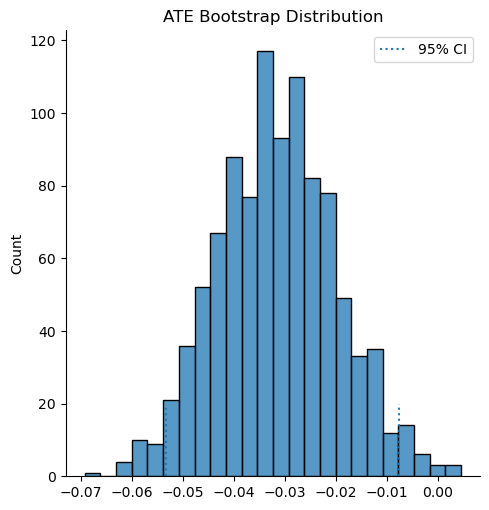

In [17]:
np.random.seed(88)
# run 1000 bootstrap samples
bootstrap_sample = 1000
ates = Parallel(n_jobs=4)(delayed(doubly_robust)(with_dummies.sample(frac=1, replace=True), X_encoded.columns.tolist(), "Counter", "polAffectiveIndex", mu0_model = LinearRegression(), mu1_model = LinearRegression())
                          for _ in range(bootstrap_sample))
ates = np.array(ates)

print(f"ATE 95% CI:", (np.percentile(ates, 2.5), np.percentile(ates, 97.5)))

sns.displot(ates, kde=False)
plt.vlines(np.percentile(ates, 2.5), 0, 20, linestyles="dotted")
plt.vlines(np.percentile(ates, 97.5), 0, 20, linestyles="dotted", label="95% CI")
plt.title("ATE Bootstrap Distribution")
plt.legend()

ATE 95% CI: (np.float64(-0.05462522730151922), np.float64(-0.00783022760746023))


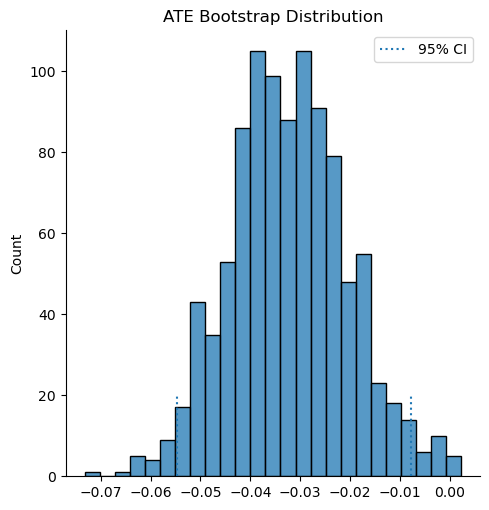

In [18]:
bootstrap_CI(with_dummies, X_encoded.columns.tolist(), 
             "Counter", "polAffectiveIndex", 
             mu0_model = LinearRegression(), mu1_model = LinearRegression(), 
             n_bootstrap=1000)

ATE 95% CI: (np.float64(-0.04896775434275832), np.float64(-0.005507608067596592))


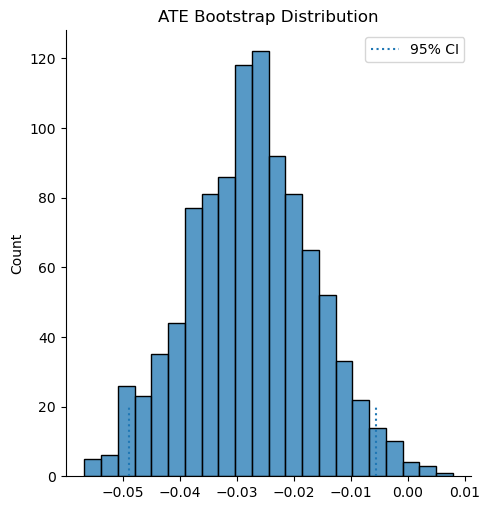

In [19]:
bootstrap_CI(with_dummies, X_encoded.columns.tolist(), 
             "Counter", "polAffectiveIndex", 
             mu0_model = RandomForestRegressor(), mu1_model = RandomForestRegressor(), 
             n_bootstrap=1000)

ATE 95% CI: (np.float64(-0.053496611056112295), np.float64(-0.008187979857104828))


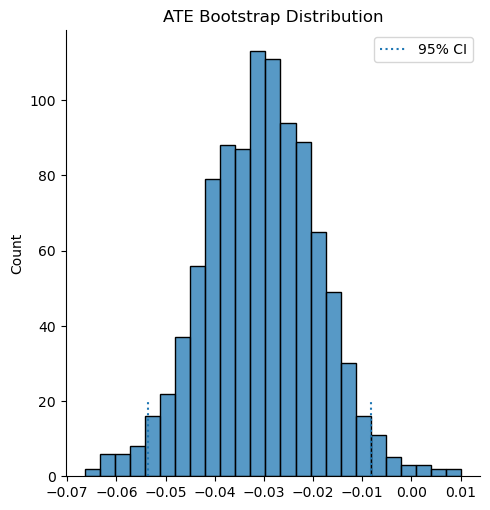

In [20]:
bootstrap_CI(with_dummies, X_encoded.columns.tolist(), 
             "Counter", "polAffectiveIndex", 
             mu0_model = LGBMRegressor(), mu1_model = LGBMRegressor(), 
             n_bootstrap=1000)